### Часть 0: Импорт библиотек

In [ ]:
import pandas as pd
import numpy as np
import os
import ast
import seaborn as sns
import joblib
from tqdm.auto import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from prophet import Prophet
import lightgbm as lgb
import optuna
from optuna.integration import LightGBMTunerCV
from prophet.serialize import model_to_json, model_from_json
import warnings
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
from IPython.display import display
import re
warnings.filterwarnings('ignore')

#  Глобальные константы 
MODEL_DIR = "trained_model_artifacts_v6_6_without_trend"
LGBM_MODEL_PATH = os.path.join(MODEL_DIR, 'lgbm_model.joblib')
SPLIT_DATE = '2020-01-01'

### Часть 1: Загрузка и обработка


In [2]:
""" 
TODO: 
    1. Добавить проверку на существование .pkl, если да — пропустить эту ячейку, иначе — выполнить `load_and_clean_data()` и сохранить.
    2. Добавить возможность прогнозировать популярность для новых треков и артистов, которые не были в обучающем датасете.
    3. Вынести имена файлов 'Result.csv', 'data_processed_without_trend.pkl', 'data_processed_for_backtest.pkl' 
    в глобальные константы в часть 0.
    4. Блоки сохранения и загрузки артефактов можно сократить. Создать словарь, где ключи - переменные, а значения - имена файлов.
    Загружать и сохранять их в цикле.
"""

#  Функция загрузки 
def load_and_clean_data():
    print("\n [Данные] Загрузка и базовая очистка ")
    df = pd.read_csv('Result.csv', on_bad_lines='skip')

    if 'trend' in df.columns:  # Удаляем колонку 'trend', чтобы избежать утечки информации
        print(" [Очистка] Удаление оригинальной колонки 'trend' для предотвращения утечки...")
        df = df.drop(columns=['trend'])
    df['date'] = pd.to_datetime(df['date'])
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df.dropna(inplace=True) # Удаляем строки, где есть хоть один NaN/NaT
    

    def get_main_artist_and_count(artists_str):
        try:
            artists_list = ast.literal_eval(artists_str) 
            if isinstance(artists_list, list) and artists_list: return artists_list[0], len(artists_list) # Если artists_str - это список, берем первый элемент(главного артиста) и считаем количество артистов в целом
        except: pass
        parts = str(artists_str).split(',')
        return parts[0].strip(), len(parts)
    df[['main_artist', 'num_artists']] = df['artists'].apply(get_main_artist_and_count).apply(pd.Series) # Добавляем колонки с главным артистом и количеством артистов
    return df

# TODO: Не вычленять главного артиста, а для каждого создавать свою строку, чтобы не терять информацию о других


# Загружаем данные
df_base = load_and_clean_data()


# Сохраняем обработанный датафрейм, чтобы не тратить время в будущем
df_base.to_pickle("data_processed_without_trend.pkl") 


 [Данные] Загрузка и базовая очистка 
 [Очистка] Удаление оригинальной колонки 'trend' для предотвращения утечки...


### Часть 2: Обучение и сохранение артефактов

In [3]:
# TODO: добавить проверку на существование переменной df_base, чтобы не читать её занво

df_base = pd.read_pickle("data_processed_without_trend.pkl") 

# Определяем список колонок, которые относятся к аудио-характеристикам трека
audio_features_cols = [
    'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness',
    'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'valence'
]

if os.path.exists(LGBM_MODEL_PATH):
    print(f" [Пропуск] Модели в папке '{MODEL_DIR}' уже существуют. Обучение не требуется.")
    RUN_TRAINING_CELLS = False
else:
    print(f" [Обучение] Готовые модели не найдены. Запускается полный цикл обучения...")
    os.makedirs(MODEL_DIR, exist_ok=True)
    RUN_TRAINING_CELLS = True
    
    # Разделяем датафрейм на обучающую и тренировочную выборки
    train_df_raw = df_base[df_base['date'] < SPLIT_DATE].copy()


    # Обогащение датафрейма признаками
    
    print("   - Расчет признаков 'силы артиста'...")
    artist_features_train = train_df_raw.groupby('main_artist').agg(
        artist_peak_streams=('streams', 'max'), 
        artist_95th_percentile_streams=('streams', lambda x: x.quantile(0.95))
    ).reset_index()
    tier_labels = ['Niche', 'Rising', 'Established', 'Superstar']
    artist_features_train['artist_tier'] = pd.qcut(artist_features_train['artist_peak_streams'], q=len(tier_labels), labels=tier_labels, duplicates='drop')
    artist_features_train = pd.get_dummies(artist_features_train, columns=['artist_tier'], prefix='tier')
    
    """
    TODO: вместо фиксированного n_components=3 для PCA, стоит построить график кумулятивной объясненной дисперсии,
    чтобы выбрать оптимальное количество компонент
    Добавить и другие признаки, сравнив результаты текущие и с новыми признаками.
    """
    print("   - Обучение PCA...")
    pca_scaler = StandardScaler() 
    pca_model = PCA(n_components=3, random_state=42) # Указываем количество компонент PCA и фиксируем random_state для воспроизводимости
    pca_model.fit(pca_scaler.fit_transform(train_df_raw[audio_features_cols])) # Обучаем PCA на масштабированных аудио-признаках
    


    """
    TODO: 
        Создание временного датафрейма `train_df_ohe_temp` только для получения имен колонок — неэффективно.
        Можно получить список колонок проще и с меньшим расходом памяти: 
            `region_cols = pd.get_dummies(train_df_raw['region'], prefix='region').columns.tolist()`.
    """

    print("   - Определение колонок регионов...")
    train_df_ohe_temp = pd.get_dummies(train_df_raw, columns=['region'], prefix='region', dummy_na=False) 
    region_cols = [col for col in train_df_ohe_temp.columns if 'region_' in col]
    del train_df_ohe_temp

    print("   - Расчет динамических признаков...")
    train_df_sorted = train_df_raw.sort_values(by=['main_artist', 'name', 'date'])
    start_streams_features = train_df_sorted.groupby(['main_artist', 'name']).head(3).copy()
    start_streams_features['day_num'] = start_streams_features.groupby(['main_artist', 'name']).cumcount() + 1
    start_streams_pivot = start_streams_features.pivot_table(index=['main_artist', 'name'], columns='day_num', values='streams').reset_index()
    start_streams_pivot.rename(columns={1: 'streams_day_1', 3: 'streams_day_3'}, inplace=True)
    start_streams_features_final = start_streams_pivot.get(['main_artist', 'name', 'streams_day_1', 'streams_day_3'], pd.DataFrame(columns=['main_artist', 'name', 'streams_day_1', 'streams_day_3']))
    
    print(" [Обучение] Обучение Prophet-моделей...")
    def train_prophet(dframe, target_col):
        market_trends = dframe.groupby('date').agg(y=(target_col, 'mean')).reset_index().rename(columns={'date': 'ds'})
        model = Prophet()
        model.fit(market_trends)
        return model
    market_model_streams = train_prophet(train_df_raw, 'streams')
    market_model_dance = train_prophet(train_df_raw, 'danceability')
    market_model_energy = train_prophet(train_df_raw, 'energy')


    print(" [Подготовка] Сборка финального обучающего датасета...")
    train_df = train_df_raw.copy()
    
    train_df[['pca_music_1', 'pca_music_2', 'pca_music_3']] = pca_model.transform(pca_scaler.transform(train_df[audio_features_cols]))
    train_df = pd.get_dummies(train_df, columns=['region'], prefix='region', dummy_na=False)
    
    train_df = pd.merge(train_df, start_streams_features_final, on=['main_artist', 'name'], how='left')
    train_df = pd.merge(train_df, artist_features_train, on='main_artist', how='left')
    
    train_df['log_streams'] = np.log1p(train_df['streams'])
    train_df.sort_values(by=['main_artist', 'name', 'date'], inplace=True)
    train_df['streams_lag_1'] = train_df.groupby(['main_artist', 'name'])['streams'].shift(1)
    train_df['streams_rolling_mean_7'] = train_df.groupby(['main_artist', 'name'])['streams'].transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
    train_df['volatility_lag_1_vs_7'] = (train_df['streams_lag_1'] / train_df['streams_rolling_mean_7']).replace([np.inf, -np.inf], np.nan)
    
    def enrich_with_market_forecast(dframe, model, col_name):
        forecast = model.predict(dframe[['date']].drop_duplicates().rename(columns={'date':'ds'}))
        return pd.merge(dframe, forecast[['ds', 'yhat']], left_on='date', right_on='ds', how='left').rename(columns={'yhat': col_name}).drop('ds', axis=1)
    train_df = enrich_with_market_forecast(train_df, market_model_streams, 'trend')
    train_df = enrich_with_market_forecast(train_df, market_model_dance, 'mean_danceability_forecast')
    train_df = enrich_with_market_forecast(train_df, market_model_energy, 'mean_energy_forecast')
    


    # Приводим типы данных Prophet-колонок к числовым
    prophet_cols = ['trend', 'mean_danceability_forecast', 'mean_energy_forecast']
    for col in prophet_cols:
        train_df[col] = pd.to_numeric(train_df[col], errors='coerce')



    print(" [Инжиниринг] Создание признаков на основе дат...")
    train_df['day_of_week'] = train_df['date'].dt.dayofweek
    train_df['day_of_year'] = train_df['date'].dt.dayofyear
    train_df['week_of_year'] = train_df['date'].dt.isocalendar().week.astype(int)
    train_df['month'] = train_df['date'].dt.month
    train_df['is_weekend'] = (train_df['date'].dt.dayofweek >= 5).astype(int)
    train_df['track_age_days'] = (train_df['date'] - train_df['release_date']).dt.days

    print(" [Инжиниринг] Заполнение пропусков...")
    feature_medians = train_df[audio_features_cols + ['streams_day_1', 'streams_day_3']].median()
    train_df.fillna(feature_medians, inplace=True)
    #train_df.fillna(0, inplace=True)


    #  Обучение LGBM                                                      
    
    print("\n [Обучение] Подготовка к обучению LightGBM...")
    tier_cols = [col for col in artist_features_train.columns if 'tier_' in col]


    #TODO: Пересмотреть, какие признаки действительно важны в финальной модели, и убрать лишние

    features = sorted(list(set([
        'track_age_days', 'num_artists', 'day_of_week', 'day_of_year', 'week_of_year', 'month', 'is_weekend',
        'pca_music_1', 'pca_music_2', 'pca_music_3',
        'streams_day_1', 'streams_day_3', 'artist_peak_streams', 'artist_95th_percentile_streams',
        'streams_lag_1', 'streams_rolling_mean_7', 'volatility_lag_1_vs_7',
        'trend', 'mean_danceability_forecast', 'mean_energy_forecast'
    ] + region_cols + tier_cols)))
        
    TARGET = 'log_streams'
        
    categorical_cols = [f for f in ['day_of_week', 'month', 'is_weekend'] + region_cols + tier_cols if f in features]
        
    X_train_full = train_df[features]
    y_train_full = train_df[TARGET]

   
    #  Сохранение типов у признаков             
    print(" [Подготовка] Сохранение информации о категориях...")
    all_categorical_info = {}


    # Собираем инфо для всех остальных категориальных колонок
    for col in categorical_cols:
        if col in X_train_full.columns and X_train_full[col].dtype.name == 'category':
            all_categorical_info[col] = X_train_full[col].cat.categories
            
    # Приводим типы в X_train_full к 'category' на всякий случай, если они слетели
    for col, categories in all_categorical_info.items():
        X_train_full[col] = pd.Categorical(X_train_full[col], categories=categories)

    print(f"   - Найдено и сохранено {len(all_categorical_info)} категориальных признаков.")
    
    #  Матрица корреляций
    print("\n [Анализ] Построение финальной матрицы корреляций...")

    # Для анализа нам нужен полный датафрейм, включая целевую переменную
    df_for_corr = X_train_full.copy()
    df_for_corr['TARGET_log_streams'] = y_train_full

    # Так как LightGBM работает с категориальными признаками, а .corr() - только с числовыми,
    # Явно выбираем только числовые колонки для матрицы.
    numerical_cols_for_corr = df_for_corr.select_dtypes(include=np.number).columns
    df_numerical_for_corr = df_for_corr[numerical_cols_for_corr]

    # Строим матрицу корреляций
    try:    
        plt.figure(figsize=(24, 22))
        correlation_matrix = df_numerical_for_corr.corr()
        sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
        plt.title('Финальная матрица корреляций признаков', fontsize=16)
        plt.tight_layout()
        plt.show()

        print("\n Топ-15 признаков, наиболее скоррелированных ")
        corr_with_target = correlation_matrix['TARGET_log_streams'].abs().sort_values(ascending=False)
        print(corr_with_target[1:16]) # [1:16] чтобы не выводить корреляцию цели с самой собой

    except Exception as e:
        print(f"Не удалось построить матрицу корреляций. Ошибка: {e}")

   

    dtrain = lgb.Dataset(X_train_full, label=y_train_full, categorical_feature=categorical_cols)
        
    print(" [Обучение] Подбор гиперпараметров с Optuna...")

    def objective(trial):
        # Определяем пространство поиска гиперпараметров
        param = {
            "objective": "regression_l1",
            "metric": "l1", 
            "verbosity": -1,
            "boosting_type": "gbdt",
            "random_state": 42,
            "n_estimators": 1000, # Большое число, early stopping найдет оптимум
            "feature_pre_filter": False,
            "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
            "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
            "num_leaves": trial.suggest_int("num_leaves", 2, 256),
            "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
            "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
            "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        }

        # Используем кросс-валидацию для оценки параметров
        pruning_callback = optuna.integration.LightGBMPruningCallback(trial, "l1")
        cv_results = lgb.cv(
            param,
            dtrain,
            nfold=5,
            stratified=False,
            callbacks=[pruning_callback, lgb.early_stopping(50, verbose=False)],
            seed=42
        )
            
        # Сохраняем лучшее количество итераций
        best_iteration = len(cv_results['valid l1-mean'])
        trial.set_user_attr("best_iteration", best_iteration)

        # Возвращаем метрику для оптимизации
        mean_mae = cv_results['valid l1-mean'][-1]
        return mean_mae

    # Запускаем оптимизацию
    study = optuna.create_study(direction="minimize", pruner=optuna.pruners.MedianPruner())
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    print("Подбор гиперпараметров завершен.")
    print(f"Лучшее значение MAE на CV: {study.best_value:.4f}")
    print("Лучшие параметры:", study.best_params)

    # Получаем оптимальное количество деревьев из лучшего trial
    best_n_estimators = study.best_trial.user_attrs.get("best_iteration", 1000)
    print(f"Оптимальное количество деревьев: {best_n_estimators}")

    # Собираем финальные параметры для обучения
    final_params = {
        "objective": "regression_l1",
        "metric": "l1",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "random_state": 42,
        "n_estimators": best_n_estimators
    }
    final_params.update(study.best_params)

    print(" [Обучение] Обучение финальной модели на лучших параметрах...")
    lgbm_model_frozen = lgb.LGBMRegressor(**final_params)
    lgbm_model_frozen.fit(X_train_full, y_train_full, categorical_feature=categorical_cols)
    


    # Сохранение артефактов и модели
    print(f"\n [Сохранение] Сохранение моделей и артефактов в папку '{MODEL_DIR}'...")
    joblib.dump(lgbm_model_frozen, LGBM_MODEL_PATH)
    with open(os.path.join(MODEL_DIR, 'prophet_model_streams.json'), 'w') as f: f.write(model_to_json(market_model_streams))
    with open(os.path.join(MODEL_DIR, 'prophet_model_dance.json'), 'w') as f: f.write(model_to_json(market_model_dance))
    with open(os.path.join(MODEL_DIR, 'prophet_model_energy.json'), 'w') as f: f.write(model_to_json(market_model_energy))
    joblib.dump(pca_scaler, os.path.join(MODEL_DIR, 'pca_scaler.joblib'))
    joblib.dump(pca_model, os.path.join(MODEL_DIR, 'pca_model.joblib'))
    joblib.dump(region_cols, os.path.join(MODEL_DIR, 'region_cols.joblib'))
    joblib.dump(start_streams_features_final, os.path.join(MODEL_DIR, 'start_streams_features.joblib'))
    joblib.dump(artist_features_train, os.path.join(MODEL_DIR, 'artist_features_train.joblib'))
    joblib.dump(feature_medians, os.path.join(MODEL_DIR, 'feature_medians.joblib'))
    joblib.dump(features, os.path.join(MODEL_DIR, 'features_list.joblib'))
    joblib.dump(all_categorical_info, os.path.join(MODEL_DIR, 'all_categorical_info.joblib'))
    
    print(" Полный цикл обучения и сохранения завершен.")

 [Пропуск] Модели в папке 'trained_model_artifacts_v6_6_without_trend' уже существуют. Обучение не требуется.


### Часть 3: Анализ важности признаков

 [Загрузка] Загрузка модели из 'trained_model_artifacts_v6_6_without_trend\lgbm_model.joblib'...
 Модель успешно загружена.

 Анализ важности признаков 

 Топ-20 самых важных признаков по мнению модели:
                           feature  importance
86                  track_age_days       18579
78                   streams_day_1       15942
9                      pca_music_1       15816
79                   streams_day_3       15573
1              artist_peak_streams       15428
0   artist_95th_percentile_streams       15371
10                     pca_music_2       14768
7                            month       14699
11                     pca_music_3       14587
80                   streams_lag_1       13844
81          streams_rolling_mean_7       13431
88           volatility_lag_1_vs_7       12264
6             mean_energy_forecast        8327
3                      day_of_year        7209
5       mean_danceability_forecast        5527
8                      num_artists        358

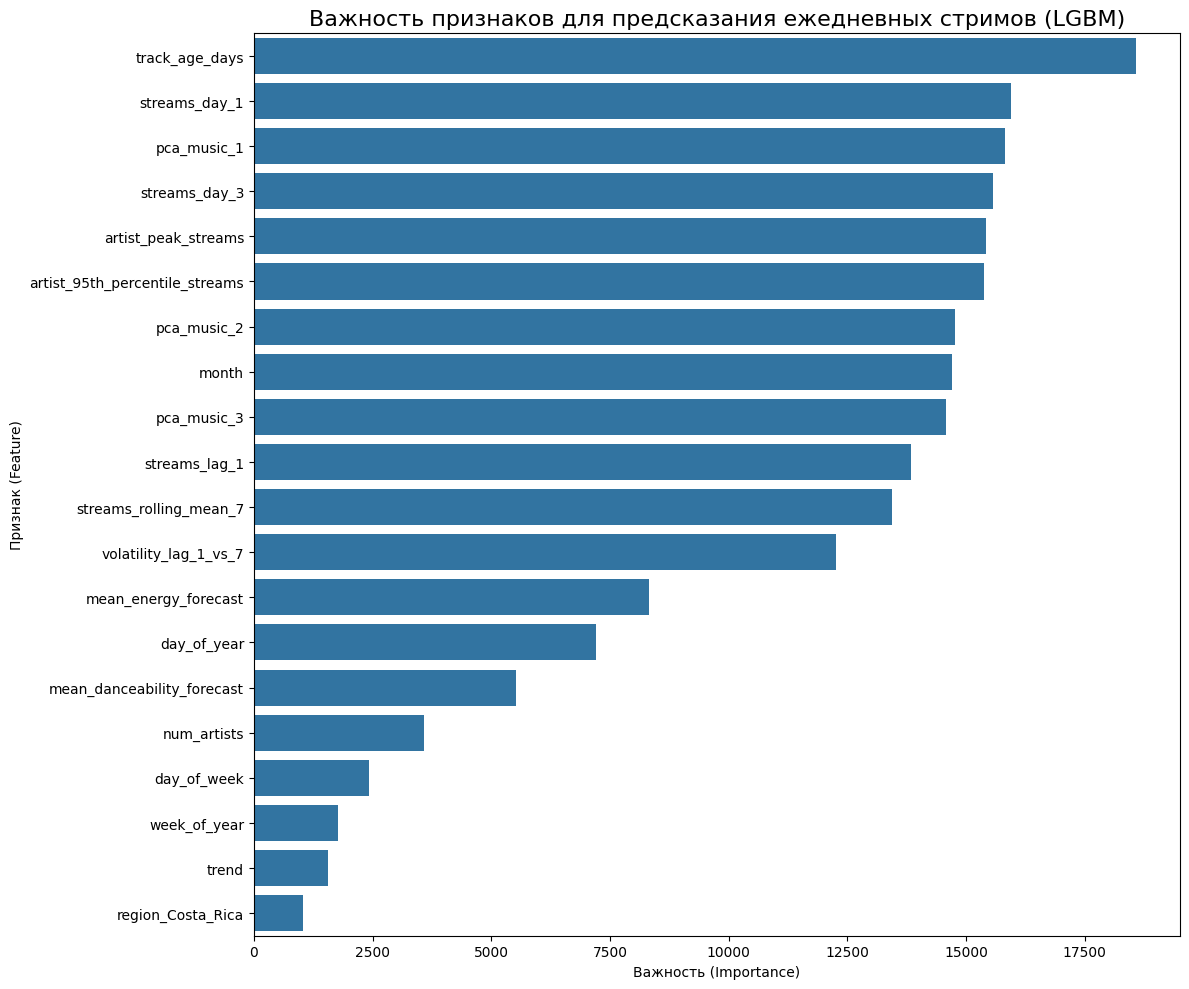

In [4]:
#  Загрузка уже обученной модели 
print(f" [Загрузка] Загрузка модели из '{LGBM_MODEL_PATH}'...")
try:
    lgbm_model_frozen = joblib.load(LGBM_MODEL_PATH)
    print(" Модель успешно загружена.")
except FileNotFoundError:
    print(f"ОШИБКА: Файл модели не найден по пути '{LGBM_MODEL_PATH}'.")

if 'lgbm_model_frozen' in locals():
    #  Анализ важности признаков 
    print("\n Анализ важности признаков ")

    # Получаем важность и имена признаков из объекта модели
    feature_importance = pd.DataFrame({
        'feature': lgbm_model_frozen.feature_name_,
        'importance': lgbm_model_frozen.feature_importances_
    }).sort_values('importance', ascending=False)

    print("\n Топ-20 самых важных признаков по мнению модели:")
    print(feature_importance.head(20))

    # Построение графика важности признаков
    plt.figure(figsize=(12, 10))
    sns.barplot(x='importance', y='feature', data=feature_importance.head(20))
    plt.title('Важность признаков для предсказания ежедневных стримов (LGBM)', fontsize=16)
    plt.xlabel('Важность (Importance)')
    plt.ylabel('Признак (Feature)')
    plt.tight_layout()
    plt.show()

In [5]:
# TODO: Внести в ячейку ниже и добавить проверку на существование переменной df_base, чтобы не читать её заново
df_base = pd.read_pickle("data_processed_without_trend.pkl")

### Часть 4: Загрузка артефактов и подготовка данных для бэктеста

In [6]:
print(" Загрузка всех обученных компонентов...")
try:
    lgbm_model_frozen = joblib.load(LGBM_MODEL_PATH)
    with open(os.path.join(MODEL_DIR, 'prophet_model_streams.json'), 'r') as f: market_model_streams = model_from_json(f.read())
    with open(os.path.join(MODEL_DIR, 'prophet_model_dance.json'), 'r') as f: market_model_dance = model_from_json(f.read())
    with open(os.path.join(MODEL_DIR, 'prophet_model_energy.json'), 'r') as f: market_model_energy = model_from_json(f.read())
    
    pca_scaler = joblib.load(os.path.join(MODEL_DIR, 'pca_scaler.joblib'))
    pca_model = joblib.load(os.path.join(MODEL_DIR, 'pca_model.joblib'))
    region_cols = joblib.load(os.path.join(MODEL_DIR, 'region_cols.joblib'))
    start_streams_features_final = joblib.load(os.path.join(MODEL_DIR, 'start_streams_features.joblib'))
    artist_features_train = joblib.load(os.path.join(MODEL_DIR, 'artist_features_train.joblib'))
    feature_medians = joblib.load(os.path.join(MODEL_DIR, 'feature_medians.joblib'))
    features = joblib.load(os.path.join(MODEL_DIR, 'features_list.joblib'))
    all_categorical_info = joblib.load(os.path.join(MODEL_DIR, 'all_categorical_info.joblib'))
    

    """
    TODO: 
        Сохранить список колонок как артефакт и загружать его в нужных местах, 
        чтобы не допускать несостыковок обучающих и тестовых данных
    """
    audio_features_cols = [
        'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness',
        'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'valence'
    ]
    print(" Артефакты успешно загружены.")
except FileNotFoundError as e:
    print(f"ОШИБКА: Не удалось загрузить артефакт '{e.filename}'.")
    raise

# Функция для трансформации данных
def transform_dataframe(df_to_transform):
    """Применяет все обученные трансформации, используя "чертеж" категорий."""
    df = df_to_transform.copy()
    
    
    # Сжимаем множество характеристик песен с помощью PCA
    df[['pca_music_1', 'pca_music_2', 'pca_music_3']] = pca_model.transform(pca_scaler.transform(df[audio_features_cols]))
    
    # Разбиваем регион на множество переменных (one-hot encoding)
    df = pd.get_dummies(df, columns=['region'], prefix='region', dummy_na=False)
    for col in region_cols:
        if col not in df.columns: df[col] = 0
            
    # Добавляем признаки артистов и треков
    df = pd.merge(df, start_streams_features_final, on=['main_artist', 'name'], how='left') 
    df = pd.merge(df, artist_features_train, on='main_artist', how='left')
    tier_cols = [col for col in artist_features_train.columns if 'tier_' in col]
    is_new_artist = df[tier_cols[0]].isnull()
    if is_new_artist.any():
        df.loc[is_new_artist, 'tier_Niche'] = 1.0
        for col in tier_cols:
            if col != 'tier_Niche': df.loc[is_new_artist, col] = 0.0
            
    # Определяем Prophet тренды
    def enrich_with_market_forecast(dframe, model, col_name):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            unique_dates = dframe[['date']].drop_duplicates().rename(columns={'date':'ds'})
            forecast = model.predict(unique_dates)
        return pd.merge(dframe, forecast[['ds', 'yhat']], left_on='date', right_on='ds', how='left').rename(columns={'yhat': col_name}).drop('ds', axis=1)

    df = enrich_with_market_forecast(df, market_model_streams, 'trend')
    df = enrich_with_market_forecast(df, market_model_dance, 'mean_danceability_forecast')
    df = enrich_with_market_forecast(df, market_model_energy, 'mean_energy_forecast')
    
    # Создаём признаки на основе дат
    df['day_of_week'] = df['date'].dt.dayofweek
    df['day_of_year'] = df['date'].dt.dayofyear
    df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
    df['month'] = df['date'].dt.month
    df['is_weekend'] = (df['date'].dt.dayofweek >= 5).astype(int)
    df['track_age_days'] = (df['date'] - df['release_date']).dt.days

    # Восстанваливаем категории признаков
    for col, categories in all_categorical_info.items():
        if col in df.columns:
            df[col] = pd.Categorical(df[col], categories=categories)
    
    # Заполняем пропуски 
    df.fillna(feature_medians, inplace=True)
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
    for col in numeric_cols:
        df[col].fillna(0, inplace=True)
    
    # Убедимся, что все колонки на месте, иначе LightGBM может выдавать ошибку
    for col in features:
        if col not in df.columns:
            df[col] = 0
            
    return df

# Применяем функцию и сохраняем датафрейм
print("\n [Подготовка] Подготовка и трансформация данных...")
df_processed = transform_dataframe(df_base.copy())
df_processed.to_pickle("data_processed_for_backtest.pkl")
print(" Файл 'data_processed_for_backtest.pkl' успешно сохранен.")

 Загрузка всех обученных компонентов...
 Артефакты успешно загружены.

 [Подготовка] Подготовка и трансформация данных...
 Файл 'data_processed_for_backtest.pkl' успешно сохранен.


### Часть 5: Бэктестинг

In [4]:
"""
TODO: 
    1. Добавить проверку на существование файла 'data_processed_for_backtest.pkl', чтобы не загружать его заново, если он уже есть.
    2. Вынести итеративное прогнозирование в отдельную функцию для лучшей читаемости и переиспользования кода.
"""
# Загрузка артефактов и модели
df_processed = pd.read_pickle("data_processed_for_backtest.pkl")
features = joblib.load(os.path.join(MODEL_DIR, 'features_list.joblib'))
lgbm_model_frozen = joblib.load(LGBM_MODEL_PATH)
all_categorical_info = joblib.load(os.path.join(MODEL_DIR, 'all_categorical_info.joblib'))

# Параметры бэктеста 
N_TRACKS_TO_TEST = 100
FORECAST_HORIZON_DAYS = 365
if 'SPLIT_DATE' not in locals(): SPLIT_DATE = '2020-01-01'
test_df_for_btest = df_processed[df_processed['date'] >= SPLIT_DATE].copy()

test_tracks_sample = test_df_for_btest[['name', 'main_artist', 'id']].drop_duplicates().sample(
    n=min(N_TRACKS_TO_TEST, len(test_df_for_btest[['name', 'main_artist', 'id']].drop_duplicates())), 
    random_state=42
)

# Основной цикл бэктестинга
backtest_results = []
for index, track in tqdm(test_tracks_sample.iterrows(), total=len(test_tracks_sample), desc="Бэктестинг треков"):
    track_id, track_name, artist_name = track['id'], track['name'], track['main_artist']
    
    # Берем ПОЛНУЮ реальную историю. Она нужна только для статических признаков.
    track_full_history = test_df_for_btest[test_df_for_btest['id'] == track_id].sort_values('date')
    if len(track_full_history) < FORECAST_HORIZON_DAYS: continue
            
    # `current_features` - это состояние "на сегодня", которое мы будем обновлять.
    # Начинаем с реальных данных первого дня.
    current_features = track_full_history.iloc[0].copy()
    
    # `history_for_lags` - переменная для хранения предсказанные значения.
    history_for_lags = pd.DataFrame() 
    # Добавляем реальный лаг для самого первого предсказания
    history_for_lags = pd.concat([history_for_lags, pd.DataFrame([{'streams': current_features['streams_lag_1']}])], ignore_index=True)
    
    daily_predictions = []

    # Итеративное прогнозирование
    for i in range(FORECAST_HORIZON_DAYS):
        # Подготовка признаков для текущего дня 
        
        # Обновляем лаговые признаки, используя НАШУ историю прогнозов
        current_features['streams_lag_1'] = history_for_lags['streams'].iloc[-1]
        rolling_mean_7 = history_for_lags['streams'].tail(7).mean()
        current_features['streams_rolling_mean_7'] = rolling_mean_7
        current_features['volatility_lag_1_vs_7'] = (current_features['streams_lag_1'] / rolling_mean_7) if rolling_mean_7 > 0 else 0
        
        # Готовим данные для модели
        X_today_df = pd.DataFrame([current_features])
        X_today_final = X_today_df[features]
        for col, categories in all_categorical_info.items():
            if col in X_today_final.columns:
                X_today_final[col] = pd.Categorical(X_today_final[col], categories=categories)
        
        # Предсказание 
        predicted_log_streams = lgbm_model_frozen.predict(X_today_final)[0]
        predicted_streams = np.expm1(predicted_log_streams).clip(0)
        
        # Сохранение результата 
        daily_predictions.append({
            'date': current_features['date'],
            'streams': track_full_history.iloc[i]['streams'], # Реальное значение для сравнения
            'predicted_streams': predicted_streams,
            'name': track_name, 'main_artist': artist_name
        })
        
        # Обновление "памяти" 
        # Добавляем в историю спрогнозированное значение
        history_for_lags = pd.concat([history_for_lags, pd.DataFrame([{'streams': predicted_streams}])], ignore_index=True)
        
        # Подготовка к следующей итерации 
        if i + 1 < FORECAST_HORIZON_DAYS:
            
            
            #Берем следующую строку из реальной истории ТОЛЬКО для обновления
            #статических признаков (день недели, возраст трека и т.д.)
            next_static_features = track_full_history.iloc[i+1].copy()
            # Переносим их в наше текущее состояние
            current_features = next_static_features
            
    if daily_predictions:
        backtest_results.append(pd.DataFrame(daily_predictions))

#  Вывод результатов 
if not backtest_results:
    print("\n Бэктестинг не дал результатов.")
else:
    full_backtest_df = pd.concat(backtest_results, ignore_index=True)
    print("\n Итеративный бэктестинг завершен.")
    print("\n Пример результатов бэктестинга:")
    print(full_backtest_df.head())

Бэктестинг треков:   0%|          | 0/100 [00:00<?, ?it/s]


 Итеративный бэктестинг завершен.

 Пример результатов бэктестинга:
        date  streams  predicted_streams            name main_artist
0 2020-01-01   3177.0        2787.308113  NI BIEN NI MAL   Bad Bunny
1 2020-01-01  23611.0       28222.591124  NI BIEN NI MAL   Bad Bunny
2 2020-01-01   1597.0        1356.972418  NI BIEN NI MAL   Bad Bunny
3 2020-01-01   1517.0        1197.121673  NI BIEN NI MAL   Bad Bunny
4 2020-01-01   2457.0        2033.703461  NI BIEN NI MAL   Bad Bunny


### Часть 6: Визуализация и анализ результатов тестирования

 [Агрегация] Суммирование результатов бэктеста по дате и треку...
 Агрегация завершена.

 [Анализ] Расчет метрик качества на агрегированных данных...

 [Отчет] Итоговые метрики качества по агрегированным прогнозам 


,WMAPE,Медианная MAPE по трекам,RMSE (Прослушивания),R-квадрат,Ошибка совокупного прогноза,Количество треков в тесте
Общий итог,27.02%,26.76%,"225,981",0.815,-17.75%,37



 [Визуализация] Примеры результатов


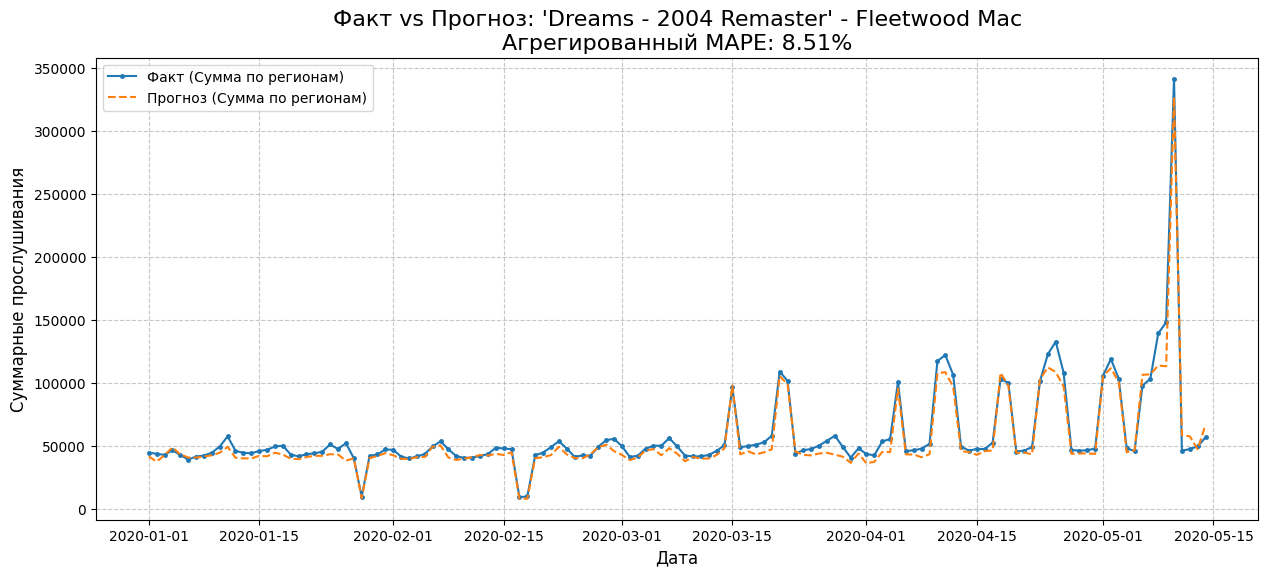

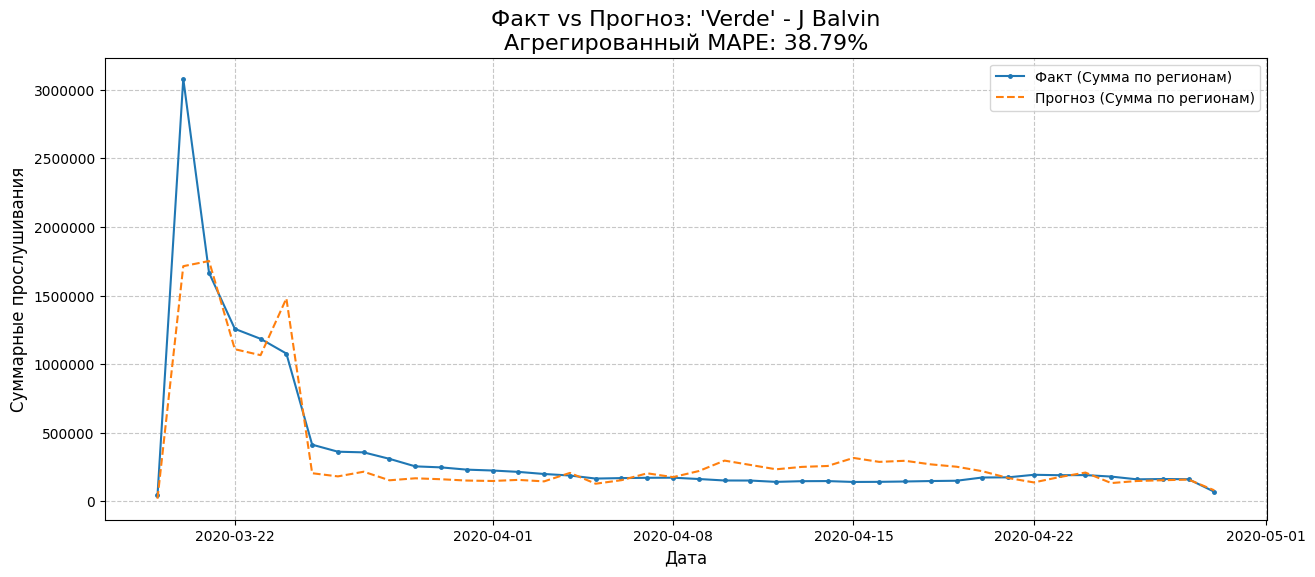

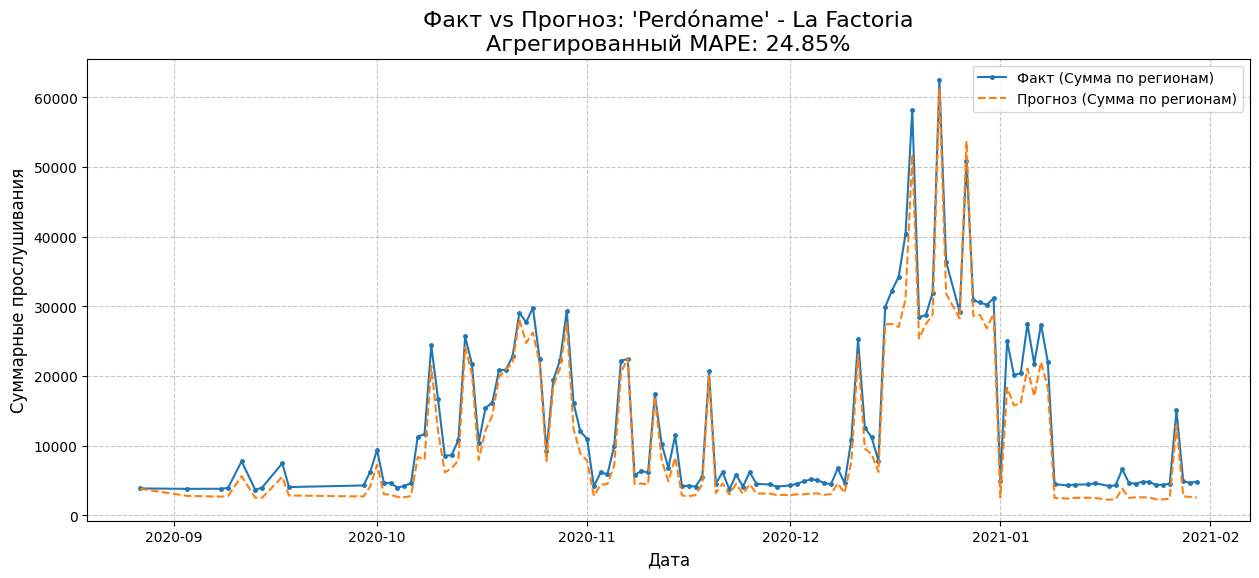

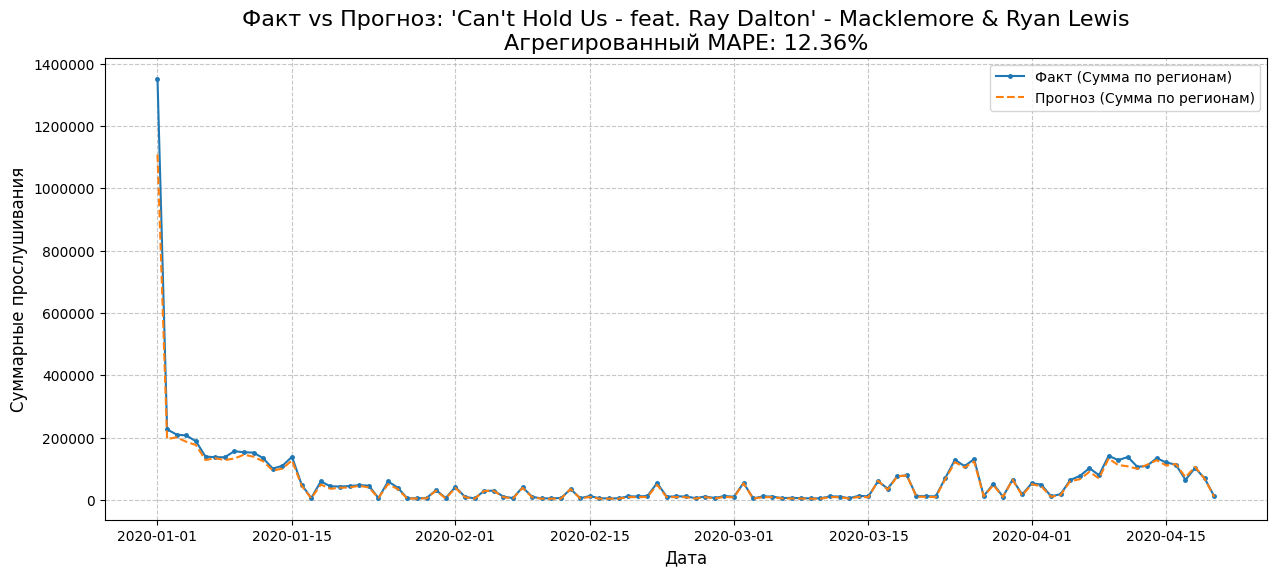

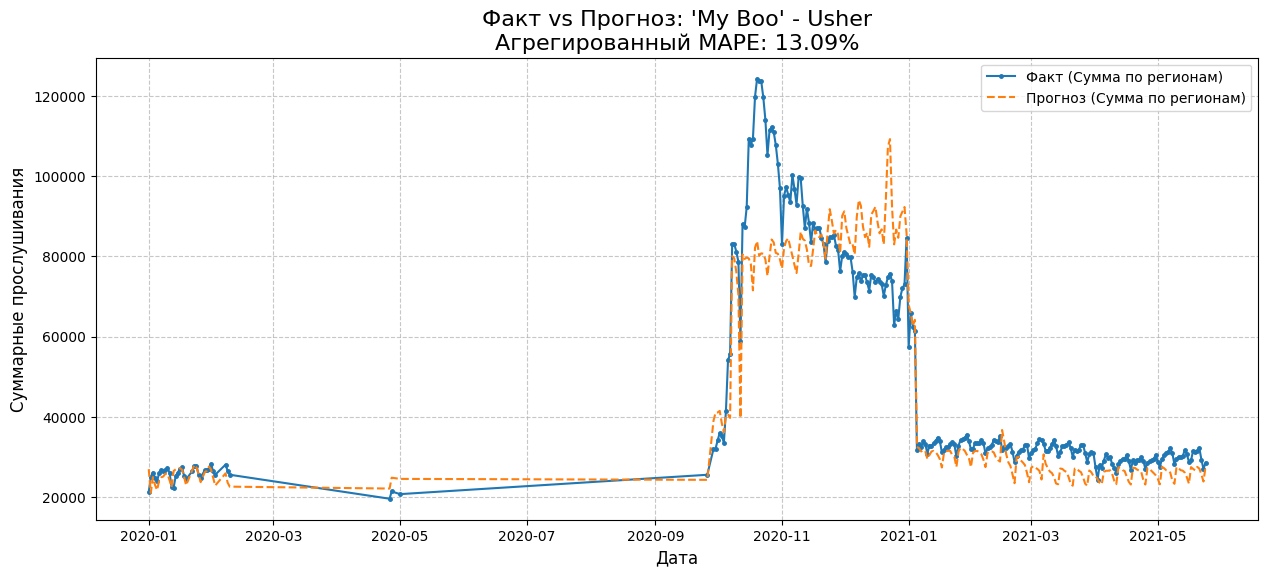

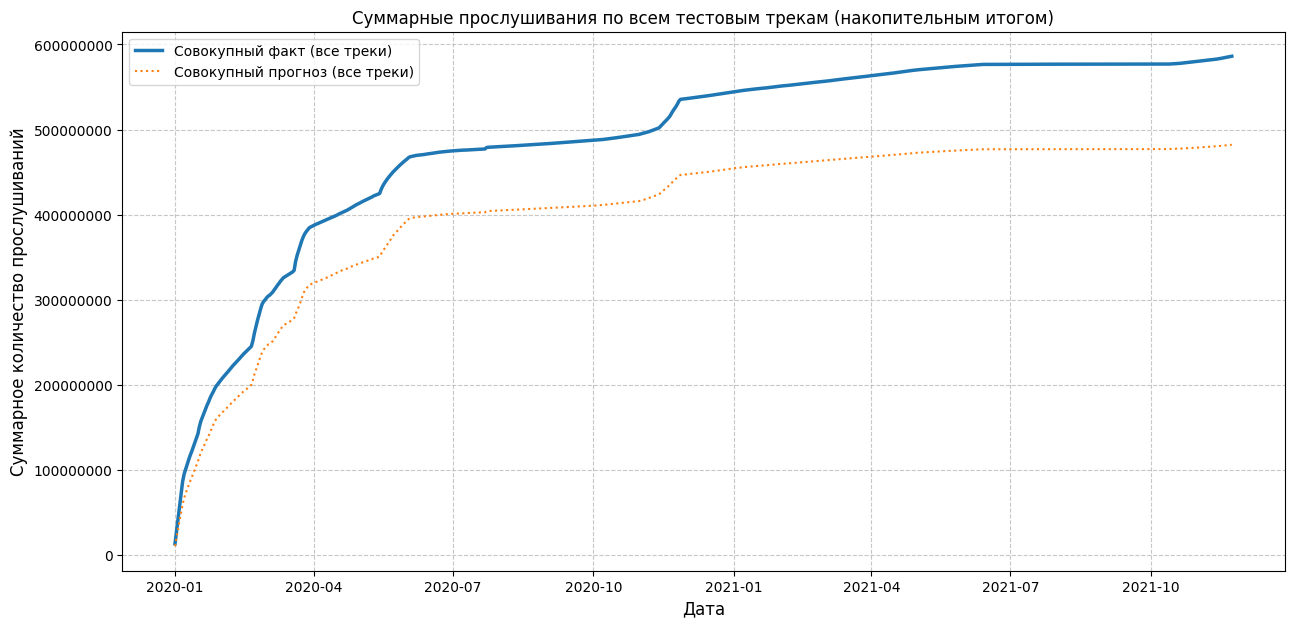

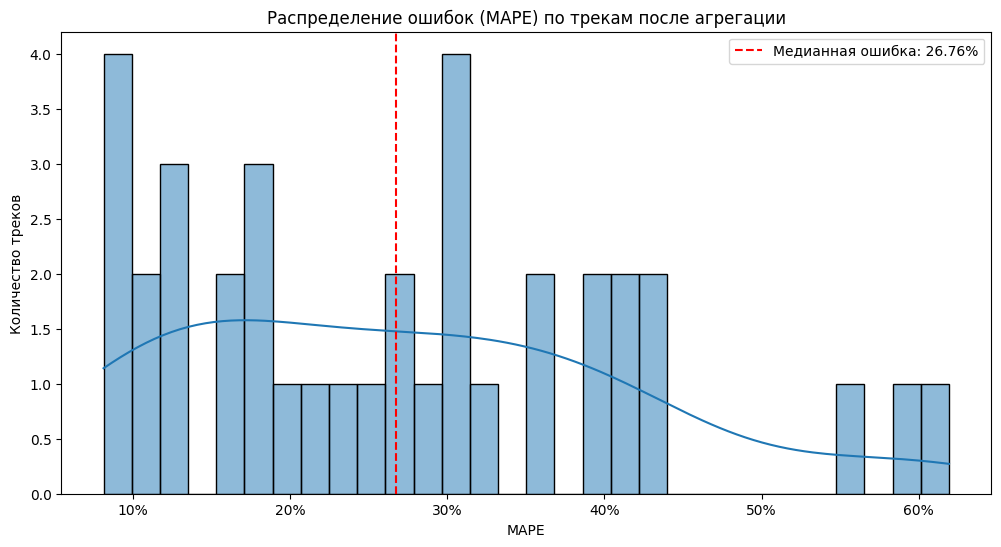

In [ ]:
"""
TODO: 
    1. Добавить возможность отображения метрик для конкретного трека/региона
    2. Добавить визуализацию для треков с наибольшим смещением(bias)
"""

# Убеждаемся, что результаты бэктеста существуют и не пусты
if 'full_backtest_df' in locals() and not full_backtest_df.empty:
    
    print(" [Агрегация] Суммирование результатов бэктеста по дате и треку...")
    agg_btest_df = full_backtest_df.groupby(['name', 'main_artist', 'date']).agg(
        streams=('streams', 'sum'),
        predicted_streams=('predicted_streams', 'sum')
    ).reset_index()
    print(" Агрегация завершена.")
    
    print("\n [Анализ] Расчет метрик качества на агрегированных данных...")
    track_errors_agg = agg_btest_df.groupby(['name', 'main_artist']).apply(
        lambda g: mean_absolute_percentage_error(g['streams'][g['streams'] > 0], g['predicted_streams'][g['streams'] > 0])
        if g['streams'].sum() > 0 else 0.0
    ).reset_index(name='mape')
    
    total_actuals_agg = agg_btest_df['streams'].sum()
    total_predicted_agg = agg_btest_df['predicted_streams'].sum()
    wmape = (agg_btest_df['streams'] - agg_btest_df['predicted_streams']).abs().sum() / total_actuals_agg if total_actuals_agg > 0 else 0.0
    rmse = np.sqrt(mean_squared_error(agg_btest_df['streams'], agg_btest_df['predicted_streams']))
    r_squared = r2_score(agg_btest_df['streams'], agg_btest_df['predicted_streams'])
    cumulative_error_pct = (total_predicted_agg - total_actuals_agg) / total_actuals_agg if total_actuals_agg > 0 else 0.0
    
    print("\n [Отчет] Итоговые метрики качества по агрегированным прогнозам ")
    report_data = {
        'WMAPE': [f"{wmape:.2%}"],
        'Медианная MAPE по трекам': [f"{track_errors_agg['mape'].median():.2%}"],
        'RMSE (Прослушивания)': [f"{rmse:,.0f}"],
        'R-квадрат': [f"{r_squared:.3f}"],
        'Ошибка совокупного прогноза': [f"{cumulative_error_pct:.2%}"],
        'Количество треков в тесте': [len(track_errors_agg)]
    }
    
    try:
        display(pd.DataFrame(report_data, index=['Общий итог']))
    except (NameError, ImportError):
        print(pd.DataFrame(report_data, index=['Общий итог']))


    # Формат: 'Имя исполнителя': 'Название трека'
    tracks_to_plot = {
        "Fleetwood Mac": "Dreams - 2004 Remaster",
        "J Balvin": "Verde",
        "La Factoria": "Perdóname",
        "Macklemore & Ryan Lewis": "Can't Hold Us - feat. Ray Dalton",
        "Usher": "My Boo"
    }

    def plot_aggregated_forecast_for_notebook(track_info):
        """
        Фильтрует данные по треку, строит график и отображает его в Jupyter.
        """
        track_df = agg_btest_df[
            (agg_btest_df['name'] == track_info['name']) & 
            (agg_btest_df['main_artist'] == track_info['main_artist'])
        ]
        
        plt.figure(figsize=(15, 6))
        plt.plot(track_df['date'], track_df['streams'], label='Факт (Сумма по регионам)', color='C0', marker='.', markersize=5, linestyle='-')
        plt.plot(track_df['date'], track_df['predicted_streams'], label='Прогноз (Сумма по регионам)', color='C1', linestyle='--')
        
        mape_value = track_info['mape']
        title_text = f"Факт vs Прогноз: '{track_info['name']}' - {track_info['main_artist']}\nАгрегированный MAPE: {mape_value:.2%}"
        
        plt.title(title_text, fontsize=16)
        plt.xlabel('Дата', fontsize=12)
        plt.ylabel('Суммарные прослушивания', fontsize=12)
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.ticklabel_format(style='plain', axis='y')
        plt.show()

    print(f"\n [Визуализация] Примеры результатов")

    for artist, track_name in tracks_to_plot.items():
        # Ищем информацию о треке (включая MAPE) в ранее рассчитанном DataFrame
        track_info = track_errors_agg[
            (track_errors_agg['main_artist'] == artist) &
            (track_errors_agg['name'] == track_name)
        ]
        
        if track_info.empty:
            print(f"--- \nПРЕДУПРЕЖДЕНИЕ: Трек '{track_name}' исполнителя '{artist}' не найден в результатах бэктеста. Пропускаем.")
            continue
        
        # track_info - это DataFrame из одной строки. Берем эту строку.
        plot_aggregated_forecast_for_notebook(track_info.iloc[0])


    # Совокупный прогноз vs. Факт
    daily_totals = agg_btest_df.groupby('date')[['streams', 'predicted_streams']].sum().cumsum()
    plt.figure(figsize=(15, 7))
    plt.plot(daily_totals.index, daily_totals['streams'], label='Совокупный факт (все треки)', color='C0', linewidth=2.5)
    plt.plot(daily_totals.index, daily_totals['predicted_streams'], label='Совокупный прогноз (все треки)', color='C1', linestyle=':')
    plt.title("Суммарные прослушивания по всем тестовым трекам (накопительным итогом)")
    plt.xlabel("Дата", fontsize=12)
    plt.ylabel("Суммарное количество прослушиваний", fontsize=12)
    plt.legend()
    plt.ticklabel_format(style='plain', axis='y')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

    # Распределение ошибок MAPE
    plt.figure(figsize=(12, 6))
    sns.histplot(track_errors_agg['mape'], bins=30, kde=True)
    median_val = track_errors_agg['mape'].median()
    plt.axvline(median_val, color='red', linestyle='--', label=f'Медианная ошибка: {median_val:.2%}')
    plt.title("Распределение ошибок (MAPE) по трекам после агрегации")
    plt.xlabel("MAPE")
    plt.ylabel("Количество треков")
    plt.legend()
    plt.gca().xaxis.set_major_formatter(plt.FuncFormatter('{:.0%}'.format))
    plt.show()


else:
    print(" Результаты бэктеста ('full_backtest_df') не найдены. Запустите ячейку с бэктестом.")

### Часть 7: Анализ и интерпретация PCA

 [Загрузка] Загрузка артефактов PCA из папки 'trained_model_artifacts_v6_6_without_trend'...
Артефакты PCA успешно загружены.

 [Интерпретация PCA] Анализ компонентных нагрузок...
-> Этот анализ показывает, какие исходные аудио-признаки формируют каждую PCA-компоненту.

 Компонентные нагрузки (самые влиятельные признаки сверху) 

 pca_music_1 
energy              0.551
loudness            0.531
acousticness       -0.386
valence             0.386
danceability        0.282
instrumentalness   -0.135
mode               -0.121
key                 0.044
duration_ms        -0.033
liveness            0.022
speechiness         0.014
tempo               0.006
Name: pca_music_1, dtype: float64

 pca_music_2 
danceability        0.534
speechiness         0.485
duration_ms        -0.362
mode               -0.358
loudness           -0.248
valence             0.245
energy             -0.192
instrumentalness    0.185
acousticness        0.119
tempo              -0.088
key                 0.057
livenes

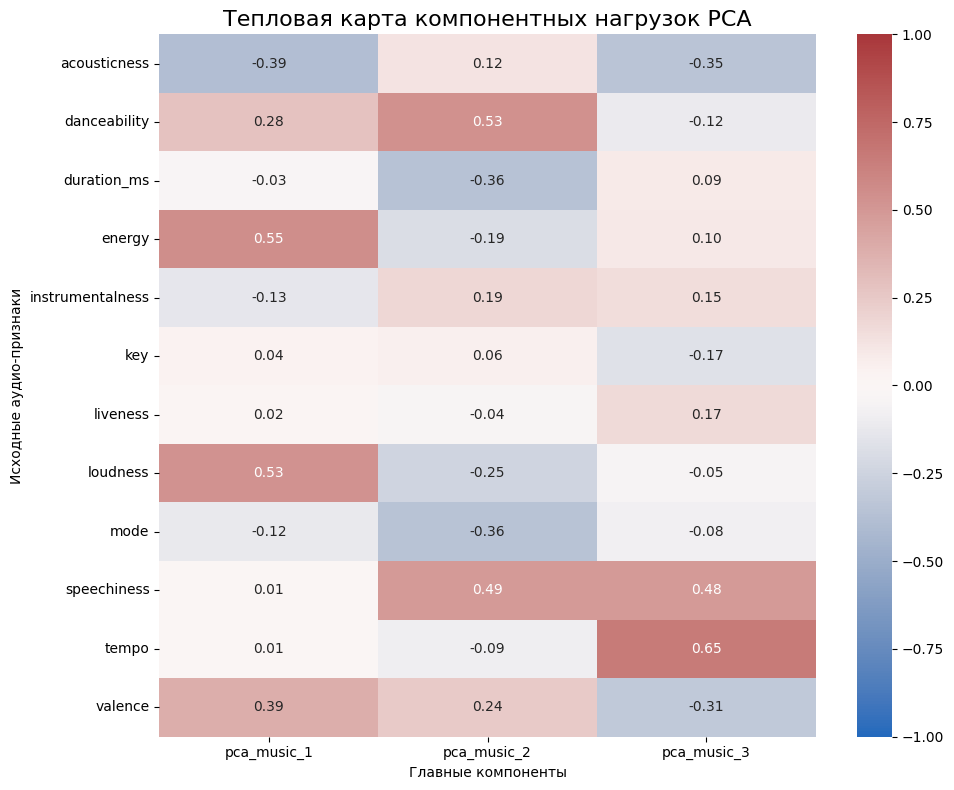

In [9]:
# TODO: Загружать audio_features_cols из артефактов для того, чтобы не допускать несостыковок обучающих и тестовых данных

print(f" [Загрузка] Загрузка артефактов PCA из папки '{MODEL_DIR}'...")
try:
    pca_model = joblib.load(os.path.join(MODEL_DIR, 'pca_model.joblib'))
    
    audio_features_cols = [
        'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness',
        'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'valence'
    ]
    
    print("Артефакты PCA успешно загружены.")
except FileNotFoundError as e:
    print(f"ОШИБКА: Не удалось загрузить артефакт '{e.filename}'.")
    print("Пожалуйста, сначала запустите ячейку обучения для модели с PCA.")

if 'pca_model' in locals():
    print("\n [Интерпретация PCA] Анализ компонентных нагрузок...")
    print("-> Этот анализ показывает, какие исходные аудио-признаки формируют каждую PCA-компоненту.")

    # Создаем DataFrame с компонентными нагрузками
    df_loadings = pd.DataFrame(
        pca_model.components_.T,
        columns=['pca_music_1', 'pca_music_2', 'pca_music_3'],
        index=audio_features_cols
    )

    print("\n Компонентные нагрузки (самые влиятельные признаки сверху) ")
    for col in df_loadings.columns:
        print(f"\n {col} ")
        sorted_loads = df_loadings[col].abs().sort_values(ascending=False)
        print(df_loadings[col].loc[sorted_loads.index].round(3))

    plt.figure(figsize=(10, 8))
    sns.heatmap(df_loadings, annot=True, cmap='vlag', fmt='.2f', vmin=-1, vmax=1)
    plt.title('Тепловая карта компонентных нагрузок PCA', fontsize=16)
    plt.ylabel('Исходные аудио-признаки')
    plt.xlabel('Главные компоненты')
    plt.tight_layout()
    plt.show()